In [3]:
import dbfold
import dbfold.utils
from dbfold.utils import substructures as subs
from dbfold import protein

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [4]:
import os
import pandas as pd
import numpy as np
import pickle
import mdtraj as md
import matplotlib.pyplot as plt
import multiprocessing as mp
import seaborn as sns
import tqdm

In [5]:
pdbroot = 'ACTB_T'
native_file = f'/n/home01/kibumpark/group_folder/p19__Actin/{pdbroot}/in_pdbs/{pdbroot}.pdb'
dist_cutoff = 7.5
homedir = f'/n/home01/kibumpark/group_folder/p19__Actin/Analysis/'
savedir = f'{homedir}/figures/'
datadir = f'{homedir}/../{pdbroot}/MCPU_run/'
eq_step = 600000000

In [7]:
prot = protein.Protein(native_file, pdbroot, homedir,savedir,datadir)
if os.path.exists(f'{datadir}/logfiles_as_dataframe.pkl'):
    prot.log_df = pd.read_pickle(f'{datadir}/logfiles_as_dataframe.pkl')
    prot.eq_step = eq_step
else:
    prot.create_log_dataframe(eq_step=eq_step)
prot.log_df = prot.log_df[prot.log_df.index.get_level_values(2) >= eq_step]
prot.get_xtc_list()
prot.dist_cutoff = dist_cutoff
prot.create_mbar(k_bias=0.02,recompute=False)

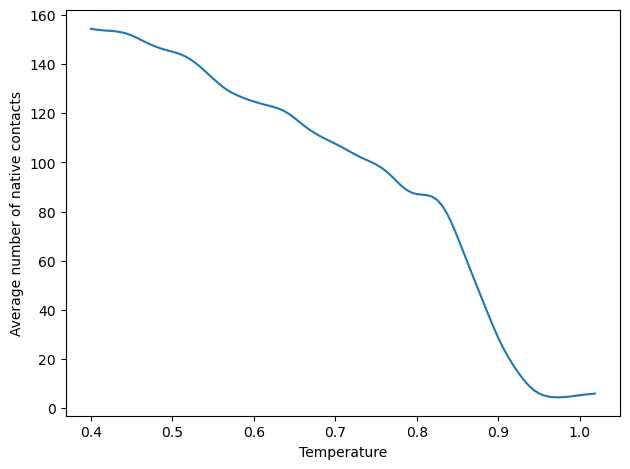

In [19]:
avg_ncontacts = []
for T in correct_temperatures:
    prot.compute_weights(T)
    avg_ncontacts.append(np.average(prot.log_df['ncontacts'],weights=prot.weights))
plt.plot(correct_temperatures,avg_ncontacts)
plt.xlabel('Temperature')
plt.ylabel('Average number of native contacts')
plt.tight_layout()
plt.savefig(f'{savedir}/avg_contacts_{pdbroot}.png')

In [ ]:
prot.define_substructure(min_seq_separation=8, contact_sep_thresh=20, min_clustersize=4)
subs.visualize_substructures(prot.native_distances, prot.substructures, prot.dist_cutoff, prot.min_seq_separation,
                            onlylower=True, savepath=f'{savedir}/{pdbroot}_substructures_nn.png')
prot.compute_score()
prot.convert_score2subs(f=1.7)
dec_subs = [subs.bin2dec(sub) for sub in prot.subs]
prot.create_fes(k_bias=0.02, recompute=False)

      feat       weights
39    1668  5.580811e-41
59    1776  1.819282e-29
61    1781  1.343292e-31
62    1784  8.466460e-30
78    2000  1.021790e-28
..     ...           ...
278  16375  4.068444e-15
279  16376  2.586256e-02
280  16380  8.016456e-08
281  16381  7.475832e-08
283  16383  3.449863e-08

[72 rows x 2 columns]
({'f_i': array([91.34454   , 64.83442   , 69.742905  , 65.59933   , 63.108723  ,
       92.76876   , 51.11488   , 47.103283  , 50.248043  , 33.259094  ,
        1.2835555 , 83.81623   , 33.471878  , 88.498795  , 91.18843   ,
       96.22309   , 95.17641   , 32.684845  , 47.749817  , 84.733     ,
       88.87648   ,  4.513037  ,  1.5359118 , 97.16614   , 40.15808   ,
       83.97276   , 80.01246   ,  5.5555773 , 75.545425  , 22.65528   ,
       41.867832  , 63.59936   , 26.193989  , 86.43221   , 64.793015  ,
       84.91257   , 28.18339   ,  8.877064  , 17.489828  , 24.872227  ,
        2.0892031 , 25.691195  ,  4.041816  ,  9.110067  ,  3.893403  ,
        9.788874  , 

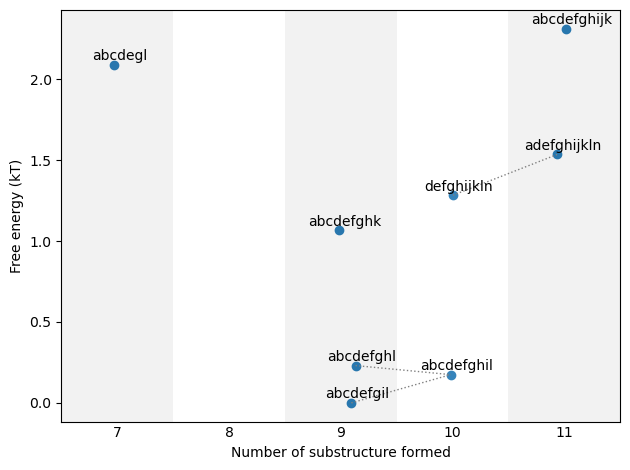

      feat       weights
12     640  1.126070e-38
17     704  1.117629e-37
22     980  2.802597e-45
31    1536  2.652704e-39
34    1572  7.006492e-45
..     ...           ...
279  16376  1.104293e-05
280  16380  6.744172e-17
281  16381  1.216244e-11
282  16382  1.130792e-34
283  16383  6.463032e-13

[121 rows x 2 columns]
({'f_i': array([ 85.7202    ,  83.42514   , 100.92648   ,  87.16594   ,
       100.01019   ,  56.597687  ,  51.712837  ,  95.91585   ,
        89.901184  ,  66.28483   ,  70.25197   ,  99.827866  ,
        26.32576   ,  80.91334   ,  90.20382   ,  63.757084  ,
        34.249584  ,  17.112343  ,  74.13984   ,  69.43447   ,
        76.57068   ,  97.275826  ,  84.305916  ,  73.56397   ,
        22.719677  ,  44.622     ,  35.414047  ,   3.4668965 ,
        54.01737   ,   4.232993  ,   0.12525284,  71.95441   ,
        55.20041   ,  59.561104  ,  51.978054  ,  25.836935  ,
        41.59333   ,  19.245768  ,  65.96101   ,  44.52751   ,
        23.635126  ,  20.842325  ,  9

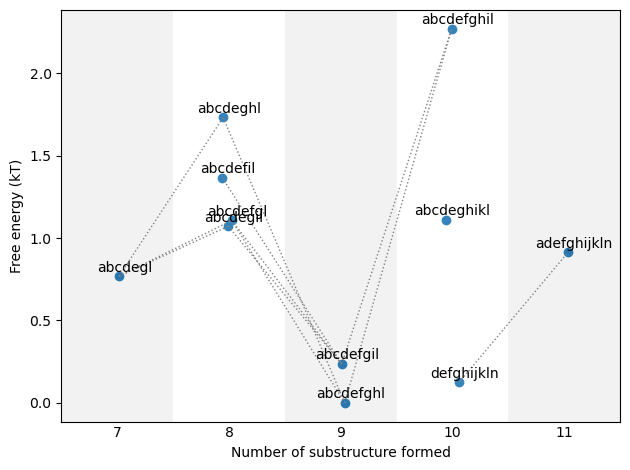

      feat       weights
0        0  3.708106e-31
1        4  5.836912e-32
5      128  2.572066e-27
6      132  2.372118e-29
8      512  1.483120e-40
..     ...           ...
279  16376  5.474827e-08
280  16380  2.078687e-17
281  16381  6.596869e-17
282  16382  1.889740e-19
283  16383  4.172731e-17

[169 rows x 2 columns]
({'f_i': array([ 68.32676   ,  70.17566   ,  59.48223   ,  64.16833   ,
        89.9664    ,  95.25755   ,  52.445377  ,  53.77102   ,
        47.7837    ,  25.8214    , 100.43746   ,  60.948284  ,
        59.05201   ,  53.593395  ,  44.16059   ,  49.68205   ,
        50.328674  ,  41.397564  ,  32.55128   ,  29.138556  ,
        40.672676  ,  44.235184  ,  34.115032  ,  49.58631   ,
        42.209232  ,  36.840565  ,  42.464844  ,  42.944397  ,
        67.04223   ,   8.968815  ,  44.930904  ,  38.048946  ,
        40.48329   ,  51.169483  ,  36.42994   ,   7.118583  ,
        44.714645  ,  32.202778  ,  34.89655   ,  37.664886  ,
        44.518047  ,  28.796263  ,  2

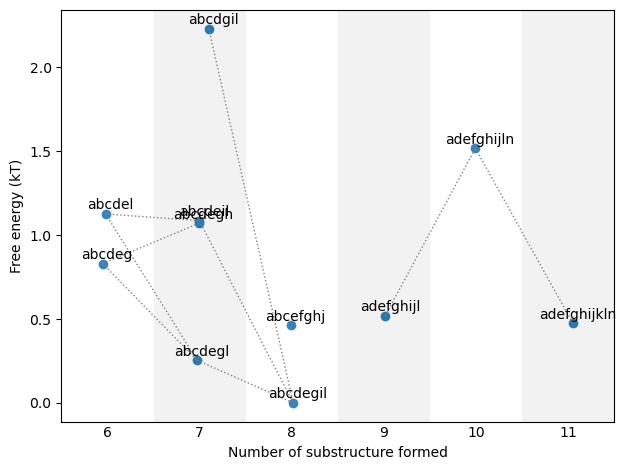

      feat       weights
0        0  5.713452e-15
1        4  6.443573e-19
2       32  6.947385e-23
3       64  1.478201e-24
4       96  2.838502e-30
..     ...           ...
279  16376  5.652665e-08
280  16380  1.552615e-15
281  16381  2.126783e-21
282  16382  1.291420e-21
283  16383  1.265399e-22

[199 rows x 2 columns]
({'f_i': array([32.338596 , 41.428677 , 50.563736 , 54.41386  , 67.57693  ,
       31.055227 , 33.08205  , 31.658453 , 31.928286 , 26.545065 ,
       46.73473  , 53.4217   , 12.170013 ,  7.8430605, 34.9268   ,
       72.97604  , 26.66938  , 27.6622   , 23.664616 , 79.73407  ,
       24.06963  , 28.104353 , 31.286423 , 27.896986 , 37.960873 ,
       55.583706 , 18.795399 , 18.65316  , 35.49065  , 98.42713  ,
       24.020607 , 16.87593  , 45.177456 , 34.502914 , 21.919594 ,
       25.658365 , 28.075624 , 16.805555 , 40.033733 , 27.892033 ,
       23.341972 , 24.850943 , 29.985582 , 81.55661  , 23.682955 ,
       30.372347 ,  8.394318 , 31.52543  , 39.29114  , 16.51038 

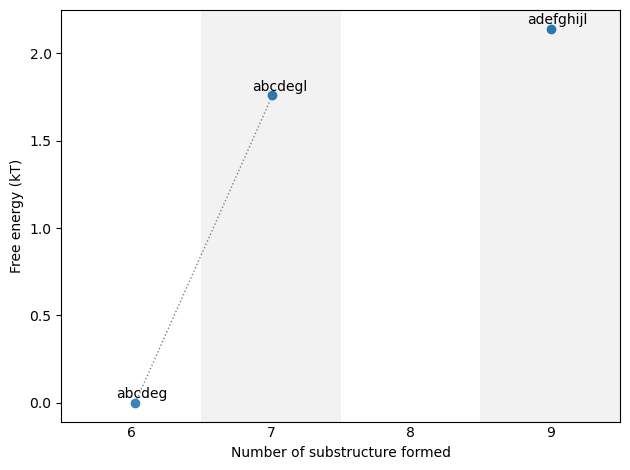

      feat       weights
0        0  2.056852e-02
1        4  3.740848e-23
2       32  2.837545e-03
3       64  2.041446e-04
4       96  8.524805e-05
..     ...           ...
279  16376  1.826604e-16
280  16380  2.203112e-19
281  16381  3.990893e-26
282  16382  1.005483e-23
283  16383  1.069201e-29

[263 rows x 2 columns]
({'f_i': array([  2.9235554,  50.679707 ,   4.904378 ,   7.536244 ,   8.409507 ,
         3.352498 ,  30.755196 , 100.70905  ,   3.5907927,  26.332054 ,
        57.783592 ,  11.060043 ,   2.2740436,  76.9042   ,  61.034016 ,
         6.5012155,  83.6256   ,   8.953784 ,  24.909851 ,  64.54176  ,
        16.271141 ,  81.54479  ,   6.8764052,  65.59499  ,   3.6442947,
        10.461079 ,   6.868357 ,  65.40017  ,  34.931053 ,  17.34623  ,
        12.55742  ,   2.432489 ,   2.948772 ,  35.043728 ,  34.21511  ,
         4.269355 ,   9.243797 ,  29.829329 ,   2.2081528,   3.8501773,
        59.168537 ,  66.51721  ,  33.34437  ,  45.38011  ,  35.737232 ,
        12.278314 ,

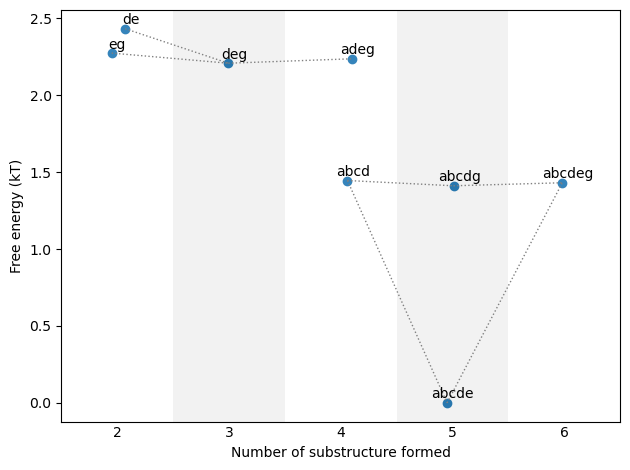

      feat       weights
0        0  8.028714e-01
1        4  3.382778e-08
2       32  7.898138e-02
3       64  1.281929e-03
4       96  1.577701e-05
..     ...           ...
278  16375  1.737610e-43
279  16376  8.022789e-31
280  16380  3.612192e-30
281  16381  1.025464e-38
282  16382  3.199298e-37

[229 rows x 2 columns]
({'f_i': array([  0.       ,  16.982424 ,   2.3189826,   6.439829 ,  10.837396 ,
         3.2852623,  81.2599   ,  35.0984   ,   4.1840563,  10.293092 ,
        19.36136  ,  45.11878  ,   4.0768113,  32.19666  ,  35.159954 ,
         9.147404 ,  36.155037 ,   8.6242285,   9.068393 ,  33.54169  ,
        28.666344 ,  42.796738 ,  39.47845  ,  37.244995 ,   3.637322 ,
         9.594862 ,  11.640361 ,  24.45447  ,  92.9547   ,  62.25049  ,
         6.3864026,   7.5805717,  16.768587 ,  16.344034 ,  91.39991  ,
        18.684725 ,  25.571657 ,  16.026377 ,  10.372945 ,  17.411512 ,
        31.084309 ,  31.926287 ,  35.593315 ,  20.035927 ,  55.245464 ,
        32.781902 ,

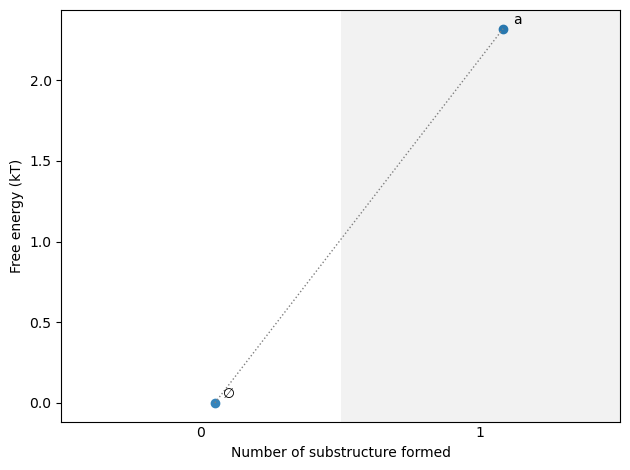

      feat       weights
0        0  9.788970e-01
1        4  2.610428e-05
2       32  5.816586e-03
3       64  8.508844e-04
4       96  2.185546e-18
..     ...           ...
269  16348  3.487552e-41
274  16368  9.295427e-37
275  16372  4.152626e-39
279  16376  1.402924e-40
280  16380  9.692781e-42

[180 rows x 2 columns]
({'f_i': array([  0.       ,  10.532083 ,   5.125713 ,   7.0479054,  40.643337 ,
         5.1620083,  12.75375  ,   5.8415155,  27.936136 ,  11.590973 ,
       102.56445  ,   9.656777 ,  23.515984 ,  37.298126 ,  11.896558 ,
        24.668676 ,  20.867647 ,  21.948875 ,  36.50991  ,  34.69282  ,
        42.194923 ,  40.48199  ,  45.03904  ,   7.7236967,  16.547712 ,
        13.756992 ,  22.171854 ,  21.914667 ,  16.45813  ,  49.86597  ,
        23.830427 ,  53.703106 ,  69.107765 ,  31.029543 ,  17.292068 ,
        51.08308  ,  24.649792 ,  41.683414 ,  46.885548 ,  21.075487 ,
        45.59556  ,  57.55841  ,  23.216724 ,  42.871307 ,  46.186573 ,
        45.666286 ,

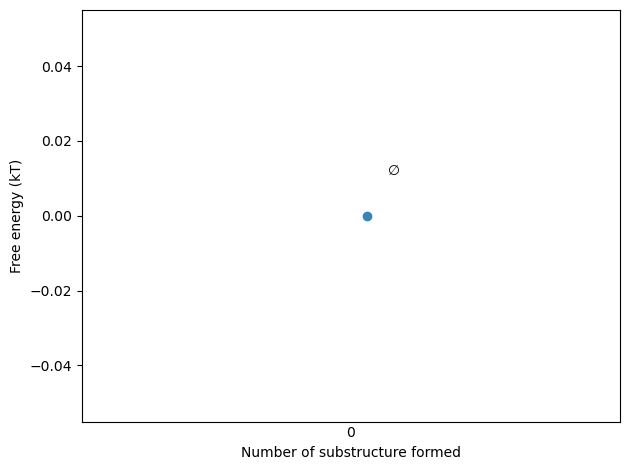

In [18]:
for T in tqdm.tqdm([0.400,0.500,0.600,0.700,0.800,0.900,1.000]):
    fes_result = prot.compute_fes(dec_subs,T,ftype='discrete')
    subs.plot_substructure_fes(fes_result,f"{savedir}/PMF_{pdbroot}_plot_{T}.png")